In [2]:
# EDA - Medical Transcriptions Dataset
# Goal: Understand clinical note structure, 
# visualize specialty distributions, check for bias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded")

Libraries loaded


In [3]:
df = pd.read_csv("../data/raw/mtsamples.csv", index_col=0)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 2 rows:")
df.head(2)

Shape: (4999, 5)

Columns: ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

First 2 rows:


,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


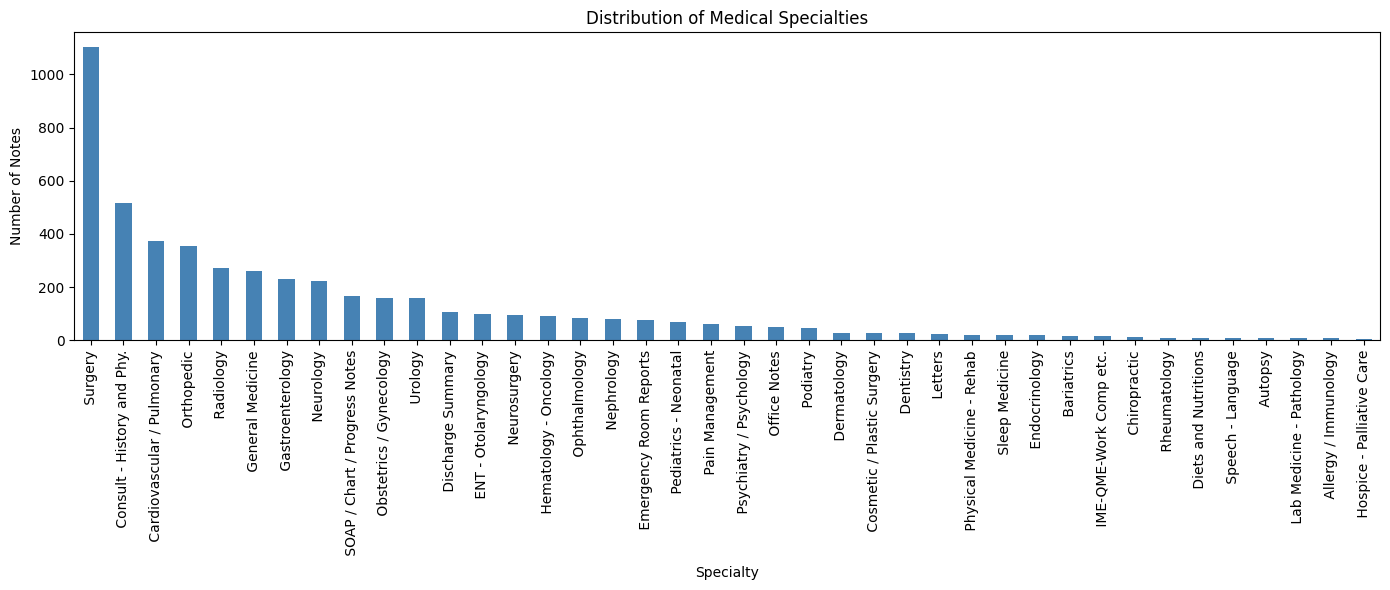

Plot saved


In [5]:
# Distribution of medical specialties
plt.figure(figsize=(14, 6))
specialty_counts = df['medical_specialty'].value_counts()
specialty_counts.plot(kind='bar', color='steelblue')
plt.title('Distribution of Medical Specialties')
plt.xlabel('Specialty')
plt.ylabel('Number of Notes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../results/figures/01_specialty_distribution.png')
plt.show()
print("Plot saved")

In [6]:
# Look at the actual text
print("Sample transcription:")
print(df['transcription'].iloc[0][:500])
print("\nSample keywords:")
print(df['keywords'].iloc[0])

Sample transcription:
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has used Allegra also.  She used that last summer and she began using it again two weeks ago.  It does not appear to be working very well.  She has used over-the-counter sprays but no prescription nasal spr

Sample keywords:
allergy / immunology, allergic rhinitis, allergies, asthma, nasal sprays, rhinitis, nasal, erythematous, allegra, sprays, allergic,


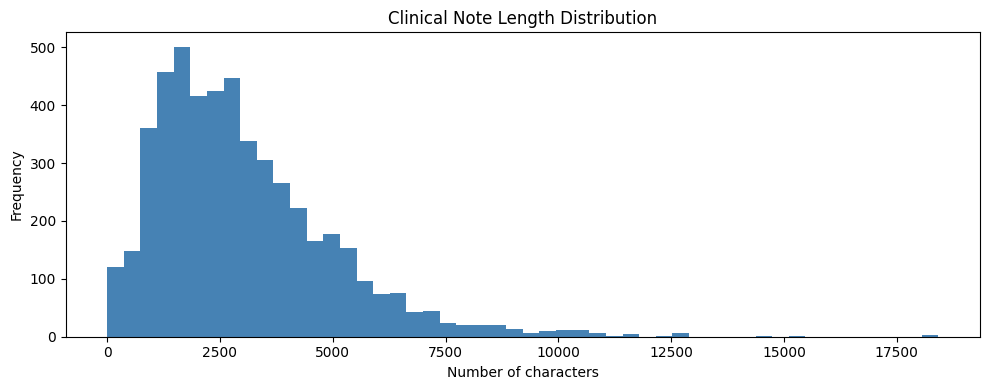

Plot saved


In [7]:
# Note length distribution
df['note_length'] = df['transcription'].fillna('').apply(len)

plt.figure(figsize=(10, 4))
df['note_length'].plot(kind='hist', bins=50, color='steelblue')
plt.title('Clinical Note Length Distribution')
plt.xlabel('Number of characters')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../results/figures/02_note_length_distribution.png')
plt.show()
print("Plot saved")

In [8]:
# Focus on top 10 specialties for modeling
top10 = specialty_counts.head(10).index.tolist()
df_top10 = df[df['medical_specialty'].isin(top10)].copy()

print("Top 10 specialties:")
print(specialty_counts.head(10))
print(f"\nFiltered dataset size: {df_top10.shape}")

Top 10 specialties:
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Name: count, dtype: int64

Filtered dataset size: (3657, 6)
